# CorrDiff Ensemble Inference with Custom Checkpoints

Advanced workflow for CorrDiff ensemble generation using your trained PhysicsNeMo checkpoints on Earth2Studio.

## Features
- **Ensemble Generation**: Generate multiple realizations with different seeds
- **Sampling Control**: Choose between deterministic and stochastic sampling
- **NetCDF Output**: Organize ensembles like PhysicsNeMo with truth/prediction/input groups
- **Statistical Analysis**: Compute ensemble statistics and uncertainty metrics

## Overview
1. Configuration with ensemble parameters
2. Load custom models and data
3. Run ensemble inference
4. Save results in organized NetCDF format
5. Visualize ensemble statistics and uncertainty

## Configuration

In [1]:
# =============================================================================
# ENSEMBLE CONFIGURATION - Update these paths and parameters for your setup
# =============================================================================

VARIABLES = "Fog_index"

# Checkpoint paths
BASE_CHECKPOINTS_PATH = "/app/host/home/younes.abid/git/physicsnemo/outputs/checkpoints/"

REGRESSION_CHECKPOINT = BASE_CHECKPOINTS_PATH + VARIABLES + '/checkpoints_regression/UNet.0.390000.mdlus'
DIFFUSION_CHECKPOINT = BASE_CHECKPOINTS_PATH + VARIABLES + '/checkpoints_diffusion/EDMPrecondSuperResolution.0.590000.mdlus'

# Data paths
BASE_DATA_PATH = '/app/host/mnt/storage/younes.abid/physicsnemo/data/custom_data_2/'
DATA_FILE = BASE_DATA_PATH + 'ERA5_WRF_combined_concatenated_432/2024-04-30_2024-05-30_21.nc'
STATS_FILE = BASE_DATA_PATH + 'stats_432/stat.json'

# Variables
INPUT_VARIABLES = ['t_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp']
OUTPUT_VARIABLES = ['Fog_index']

# Domain coordinates (adjust to your training domain)
INPUT_GRID = {
    'lat': (19.25, 28.0, 36),   # (min, max, points)
    'lon': (116.0, 126.0, 40)   # (min, max, points)
}
OUTPUT_GRID = {
    'lat': (19.0, 28.0, 432),   # (min, max, points) 
    'lon': (116.0, 126.0, 432)  # (min, max, points)
}

# =============================================================================
# ENSEMBLE PARAMETERS - Key ensemble generation settings
# =============================================================================

# Inference settings
INFERENCE_TIMES = ['2024-05-01T00:00:00', '2024-05-01T06:00:00', '2024-05-01T12:00:00']

# Ensemble parameters
NUM_ENSEMBLES = 8  # Number of ensemble members to generate
SEED_BASE = 42     # Base seed for reproducible ensemble generation

# Sampling configuration
SAMPLING_MODE = 'stochastic'  # 'deterministic' or 'stochastic'
NUMBER_OF_STEPS = 20          # Number of diffusion sampling steps
SOLVER = 'euler'              # Diffusion solver: 'euler' or 'heun'

# High-resolution mean conditioning (recommended for better results)
HR_MEAN_CONDITIONING = True

# Output configuration
from datetime import datetime
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
OUTPUT_FILE = f'/app/outputs/generation/{VARIABLES}/{TIMESTAMP}/ensemble.nc'

print('✅ Ensemble configuration loaded')
print(f'📊 Ensemble setup: {NUM_ENSEMBLES} members, {SAMPLING_MODE} sampling')
print(f'🔄 Diffusion steps: {NUMBER_OF_STEPS}, solver: {SOLVER}')
print(f'💾 Output: {OUTPUT_FILE}')

✅ Ensemble configuration loaded
📊 Ensemble setup: 8 members, stochastic sampling
🔄 Diffusion steps: 20, solver: euler
💾 Output: /app/outputs/generation/Fog_index/20260203_134413/ensemble.nc


## Setup and Imports

In [2]:
import os
import sys
import torch
import numpy as np
import xarray as xr
import netCDF4 as nc
from collections import OrderedDict
from pathlib import Path

# Add tutorials path
tutorials_path = '/app/host/home/younes.abid/git/earth2studio/notebooks/tutorials'
sys.path.append(tutorials_path)

# Earth2Studio imports
from earth2studio.data import prep_data_array
from earth2studio.io import ZarrBackend
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array
from earth2studio.models.batch import batch_coords, batch_func
from earth2studio.models.dx.base import DiagnosticModel
from earth2studio.utils import handshake_coords, handshake_dim

# PhysicsNeMo imports
from physicsnemo.models import Module as PhysicsNemoModule
from physicsnemo.utils.generative import StackedRandomGenerator, deterministic_sampler, stochastic_sampler

# Custom data loader
from custom_data_loader import CustomCorrDiffDataSource

print('✅ All imports successful')

✅ All imports successful


## Data Source Setup

In [3]:
# Create data source
data_source = CustomCorrDiffDataSource(
    data_paths=[DATA_FILE],
    stats_path=STATS_FILE,
    input_variables=INPUT_VARIABLES,
    output_variables=OUTPUT_VARIABLES,
    cache_data=True
)

print('✅ Data source created')
print(f'📊 Available samples: {data_source.total_samples}')
print(f'📐 Input grid shape: {data_source.input_shape}')

🔍 Analyzing data files...
  File 1: 2024-04-30_2024-05-30_21.nc - 504 samples
✅ Total samples across all files: 504
📐 Input grid shape: (432, 432)
📐 Lat range: [19.25, 28.00]
📐 Lon range: [116.00, 125.98]
✅ Loaded normalization stats for 16 input variables
💾 Preloading data into memory...
  Loading file 1/1: 2024-04-30_2024-05-30_21.nc
    ✅ Loaded in 6.23s
✅ Data preloading complete!
✅ Data source created
📊 Available samples: 504
📐 Input grid shape: (432, 432)


## Ensemble CorrDiff Model Definition

In [4]:
class EnsembleFogIndexCorrDiff(torch.nn.Module, DiagnosticModel):
    """Ensemble CorrDiff model for Fog_index predictions with configurable sampling"""
    
    def __init__(self, regression_model, residual_model=None, sampling_config=None):
        super().__init__()
        self.regression_model = regression_model
        self.residual_model = residual_model
        
        # Sampling configuration
        self.sampling_config = sampling_config or {}
        self.sampling_mode = self.sampling_config.get('mode', 'stochastic')
        self.num_steps = self.sampling_config.get('num_steps', 20)
        self.solver = self.sampling_config.get('solver', 'euler')
        self.hr_mean_conditioning = self.sampling_config.get('hr_mean_conditioning', True)
        
        # Grid coordinates
        self.input_lat = np.linspace(*INPUT_GRID['lat'])
        self.input_lon = np.linspace(*INPUT_GRID['lon'])
        self.output_lat = np.linspace(*OUTPUT_GRID['lat'])
        self.output_lon = np.linspace(*OUTPUT_GRID['lon'])
        
        # Normalization (extract from data source)
        self.register_buffer('in_center', torch.from_numpy(data_source.input_mean))
        self.register_buffer('in_scale', torch.from_numpy(data_source.input_std))
        self.register_buffer('out_center', torch.from_numpy(data_source.output_mean) if hasattr(data_source, 'output_mean') else torch.zeros(len(OUTPUT_VARIABLES), 1, 1))
        self.register_buffer('out_scale', torch.from_numpy(data_source.output_std) if hasattr(data_source, 'output_std') else torch.ones(len(OUTPUT_VARIABLES), 1, 1))
        
        # Ensemble parameters
        self.number_of_samples = NUM_ENSEMBLES
        self.ensemble_seeds = None  # Will be set during inference
    
    def set_ensemble_seeds(self, base_seed=42):
        """Generate ensemble seeds for reproducible sampling"""
        np.random.seed(base_seed)
        self.ensemble_seeds = np.random.randint(0, 2**31, size=self.number_of_samples)
        print(f'🎲 Generated {len(self.ensemble_seeds)} ensemble seeds: {self.ensemble_seeds[:5]}...')
    
    def input_coords(self):
        return OrderedDict({
            'batch': np.empty(0),
            'variable': np.array(INPUT_VARIABLES),
            'lat': self.input_lat,
            'lon': self.input_lon,
        })
    
    @batch_coords()
    def output_coords(self, input_coords):
        output_coords = OrderedDict({
            'batch': np.empty(0),
            'sample': np.arange(self.number_of_samples),
            'variable': np.array(OUTPUT_VARIABLES),
            'lat': self.output_lat,
            'lon': self.output_lon,
        })
        
        # Validate input
        target = self.input_coords()
        handshake_dim(input_coords, 'lon', 3)
        handshake_dim(input_coords, 'lat', 2)
        handshake_dim(input_coords, 'variable', 1)
        handshake_coords(input_coords, target, 'lon')
        handshake_coords(input_coords, target, 'lat')
        handshake_coords(input_coords, target, 'variable')
        
        output_coords['batch'] = input_coords['batch']
        return output_coords
    
    def _interpolate(self, x):
        """Interpolate to output resolution"""
        if x.shape[-2:] == (len(self.output_lat), len(self.output_lon)):
            return x
        
        # Add batch dim if needed
        if len(x.shape) == 3:
            x = x.unsqueeze(0)
            added_batch = True
        else:
            added_batch = False
        
        # Interpolate
        import torch.nn.functional as F
        target_size = (len(self.output_lat), len(self.output_lon))
        x = F.interpolate(x, size=target_size, mode='bilinear', align_corners=True)
        
        # Remove batch dim if added
        if added_batch:
            x = x.squeeze(0)
        
        return x
    
    @torch.inference_mode()
    def _forward(self, x):
        """Forward pass with ensemble generation"""
        # Interpolate and normalize
        x = self._interpolate(x)
        x = (x - self.in_center) / self.in_scale
        
        # Add sample dimension
        x = x.unsqueeze(0).repeat(self.number_of_samples, 1, 1, 1)
        
        # Create output tensors
        img_h, img_w = len(self.output_lat), len(self.output_lon)
        latents = torch.zeros(self.number_of_samples, len(OUTPUT_VARIABLES), img_h, img_w, device=x.device)
        
        # Generate ensemble seeds if not set
        if self.ensemble_seeds is None:
            self.set_ensemble_seeds(SEED_BASE)
        
        if self.residual_model is not None:
            # Full diffusion mode
            print(f'🔄 Running {self.sampling_mode} sampling with {self.num_steps} steps')
            
            # Create random number generator with ensemble seeds
            rnd = StackedRandomGenerator(x.device, torch.from_numpy(self.ensemble_seeds))
            noise = rnd.randn_like(latents)
            
            # Regression step (if using HR mean conditioning)
            if self.hr_mean_conditioning:
                mean = self.regression_model(latents, x)
                # Concatenate input and regression mean for diffusion model
                x_with_mean = torch.cat([x, mean], dim=1)
            else:
                mean = torch.zeros_like(latents)
                x_with_mean = x
            
            # Choose sampling method
            if self.sampling_mode == 'deterministic':
                residual = deterministic_sampler(
                    self.residual_model, 
                    noise, 
                    x_with_mean, 
                    randn_like=rnd.randn_like, 
                    num_steps=self.num_steps,
                    solver=self.solver
                )
            elif self.sampling_mode == 'stochastic':
                residual = stochastic_sampler(
                    self.residual_model, 
                    noise, 
                    x_with_mean, 
                    randn_like=rnd.randn_like, 
                    num_steps=self.num_steps
                )
            else:
                raise ValueError(f'Unknown sampling mode: {self.sampling_mode}')
            
            x = mean + residual
        else:
            # Regression only
            print('📊 Running regression-only mode')
            x = self.regression_model(latents, x)
        
        # Denormalize
        x = self.out_scale * x + self.out_center
        return x
    
    @batch_func()
    def __call__(self, x, coords):
        output_coords = self.output_coords(coords)
        out = torch.zeros([len(v) for v in output_coords.values()], device=x.device, dtype=torch.float32)
        
        for i in range(out.shape[0]):
            out[i] = self._forward(x[i])
        
        return out, output_coords

print('✅ Ensemble model class defined')

✅ Ensemble model class defined


## Load Models

In [5]:
# Load regression model
print(f'🔄 Loading regression model: {Path(REGRESSION_CHECKPOINT).name}')
regression_model = PhysicsNemoModule.from_checkpoint(REGRESSION_CHECKPOINT).eval()

# Load diffusion model (if exists)
diffusion_model = None
if os.path.exists(DIFFUSION_CHECKPOINT):
    print(f'🔄 Loading diffusion model: {Path(DIFFUSION_CHECKPOINT).name}')
    diffusion_model = PhysicsNemoModule.from_checkpoint(DIFFUSION_CHECKPOINT).eval()
else:
    print('⚠️  No diffusion model found, using regression-only mode')

# Sampling configuration
sampling_config = {
    'mode': SAMPLING_MODE,
    'num_steps': NUMBER_OF_STEPS,
    'solver': SOLVER,
    'hr_mean_conditioning': HR_MEAN_CONDITIONING
}

# Create ensemble CorrDiff model
ensemble_corrdiff = EnsembleFogIndexCorrDiff(
    regression_model, 
    diffusion_model, 
    sampling_config=sampling_config
)

# Set ensemble seeds for reproducibility
ensemble_corrdiff.set_ensemble_seeds(SEED_BASE)

print('✅ Ensemble models loaded successfully')
print(f'🎯 Model mode: {"Full CorrDiff" if diffusion_model else "Regression-only"}')
print(f'🎲 Sampling: {SAMPLING_MODE} with {NUM_ENSEMBLES} ensemble members')

🔄 Loading regression model: UNet.0.390000.mdlus


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/module.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(


🔄 Loading diffusion model: EDMPrecondSuperResolution.0.590000.mdlus
🎲 Generated 8 ensemble seeds: [1608637542 1273642419 1935803228  787846414  996406378]...
✅ Ensemble models loaded successfully
🎯 Model mode: Full CorrDiff
🎲 Sampling: stochastic with 8 ensemble members


## Ensemble Inference Workflow

In [ ]:
def run_ensemble_inference(times, corrdiff_model, data_source, device):
    """Run ensemble inference and collect results"""
    
    print(f'🚀 Starting ensemble inference on {device}')
    print(f'📅 Processing {len(times)} time steps')
    print(f'🎯 Generating {corrdiff_model.number_of_samples} ensemble members per time step')
    
    # Move model to device
    corrdiff_model = corrdiff_model.to(device)
    
    # Storage for all results
    all_predictions = []
    all_inputs = []
    all_coords = []
    processed_times = []
    
    # Process each time step
    for i, time_step in enumerate(times):
        print(f'🔄 Processing time {i+1}/{len(times)}: {time_step}')
        
        try:
            # Load data for this time step
            time_array = to_time_array([time_step])
            x, coords = prep_data_array(
                data_source(time_array, INPUT_VARIABLES), 
                device=device
            )
            x, coords = map_coords(x, coords, corrdiff_model.input_coords())
            
            print(f'   📊 Input data shape: {x.shape}')
            
            # Store input for later saving
            all_inputs.append(x.cpu())
            
            # Run ensemble inference
            with torch.no_grad():
                pred, pred_coords = corrdiff_model(x, coords)
            
            print(f'   ✅ Generated ensemble shape: {pred.shape}')
            
            # Store results
            all_predictions.append(pred.cpu())
            all_coords.append(pred_coords)
            processed_times.append(time_array[0])
            
        except Exception as e:
            print(f'   ❌ Error processing {time_step}: {e}')
            continue
    
    print(f'✅ Ensemble inference complete! Processed {len(processed_times)} time steps')
    
    return {
        'predictions': all_predictions,
        'inputs': all_inputs,
        'coords': all_coords,
        'times': processed_times
    }

# Run the ensemble inference
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Execute ensemble inference
results = run_ensemble_inference(INFERENCE_TIMES, ensemble_corrdiff, data_source, device)

print(f'📊 Final results: {len(results["predictions"])} time steps with {NUM_ENSEMBLES} ensemble members each')

🚀 Starting ensemble inference on cuda
📅 Processing 3 time steps
🎯 Generating 8 ensemble members per time step
🔄 Processing time 1/3: 2024-05-01T00:00:00
🔄 Loading data for 1 times and 16 variables
✅ Loaded DataArray with shape: (1, 16, 432, 432)
   📊 Input data shape: torch.Size([1, 16, 36, 40])
🔄 Running stochastic sampling with 20 steps


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


   ✅ Generated ensemble shape: torch.Size([1, 8, 1, 432, 432])
🔄 Processing time 2/3: 2024-05-01T06:00:00
🔄 Loading data for 1 times and 16 variables
✅ Loaded DataArray with shape: (1, 16, 432, 432)
   📊 Input data shape: torch.Size([1, 16, 36, 40])
🔄 Running stochastic sampling with 20 steps


/usr/local/lib/python3.11/dist-packages/physicsnemo/models/diffusion/layers.py:701: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=self.amp_mode):


## Save Results in PhysicsNeMo Format

In [8]:
def save_ensemble_netcdf(results, output_path):
    """Save ensemble results in PhysicsNeMo-style NetCDF format"""
    
    print(f'💾 Saving ensemble results to: {output_path}')
    
    # Create output directory
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Create NetCDF file
    with nc.Dataset(output_path, 'w', format='NETCDF4') as f:
        
        # Global attributes
        f.title = 'CorrDiff Ensemble Predictions'
        f.description = f'Ensemble forecasts with {NUM_ENSEMBLES} members using {SAMPLING_MODE} sampling'
        f.created = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        f.sampling_mode = SAMPLING_MODE
        f.num_steps = NUMBER_OF_STEPS
        f.solver = SOLVER
        f.hr_mean_conditioning = str(HR_MEAN_CONDITIONING)
        f.base_seed = SEED_BASE
        
        # Extract dimensions
        n_times = len(results['times'])
        n_ensembles = NUM_ENSEMBLES
        n_lat = len(ensemble_corrdiff.output_lat)
        n_lon = len(ensemble_corrdiff.output_lon)
        n_input_vars = len(INPUT_VARIABLES)
        n_output_vars = len(OUTPUT_VARIABLES)
        
        print(f'   📐 Dimensions: time={n_times}, ensemble={n_ensembles}, lat={n_lat}, lon={n_lon}')
        
        # =================================================================
        # PREDICTION GROUP - Main ensemble predictions
        # =================================================================
        pred_group = f.createGroup('prediction')
        
        # Dimensions
        pred_group.createDimension('time', n_times)
        pred_group.createDimension('ensemble', n_ensembles)
        pred_group.createDimension('y', n_lat)
        pred_group.createDimension('x', n_lon)
        
        # Coordinate variables
        time_var = pred_group.createVariable('time', 'f8', ('time',))
        ens_var = pred_group.createVariable('ensemble', 'i4', ('ensemble',))
        y_var = pred_group.createVariable('y', 'f4', ('y',))
        x_var = pred_group.createVariable('x', 'f4', ('x',))
        
        # Set coordinate values
        time_var[:] = [(t - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 'h') for t in results['times']]
        time_var.units = 'hours since 1970-01-01 00:00:00'
        ens_var[:] = np.arange(n_ensembles)
        y_var[:] = ensemble_corrdiff.output_lat
        x_var[:] = ensemble_corrdiff.output_lon
        
        # Data variables for each output variable
        for var_idx, var_name in enumerate(OUTPUT_VARIABLES):
            var = pred_group.createVariable(var_name, 'f4', ('ensemble', 'time', 'y', 'x'), 
                                          compression='zlib', complevel=4)
            
            # Collect data for this variable across all times
            var_data = np.zeros((n_ensembles, n_times, n_lat, n_lon))
            for t_idx, pred in enumerate(results['predictions']):
                var_data[:, t_idx, :, :] = pred[0, :, var_idx, :, :]  # [batch, sample, variable, lat, lon]
            
            var[:] = var_data
            var.long_name = f'Ensemble predictions for {var_name}'
            var.units = 'model_units'
        
        # =================================================================
        # INPUT GROUP - Low resolution inputs
        # =================================================================
        input_group = f.createGroup('input')
        
        # Dimensions
        input_group.createDimension('time', n_times)
        input_group.createDimension('y_input', len(ensemble_corrdiff.input_lat))
        input_group.createDimension('x_input', len(ensemble_corrdiff.input_lon))
        
        # Coordinate variables
        time_input = input_group.createVariable('time', 'f8', ('time',))
        y_input = input_group.createVariable('y', 'f4', ('y_input',))
        x_input = input_group.createVariable('x', 'f4', ('x_input',))
        
        time_input[:] = time_var[:]
        time_input.units = time_var.units
        y_input[:] = ensemble_corrdiff.input_lat
        x_input[:] = ensemble_corrdiff.input_lon
        
        # Data variables for each input variable
        for var_idx, var_name in enumerate(INPUT_VARIABLES):
            var = input_group.createVariable(var_name, 'f4', ('time', 'y_input', 'x_input'),
                                            compression='zlib', complevel=4)
            
            # Collect input data across all times
            var_data = np.zeros((n_times, len(ensemble_corrdiff.input_lat), len(ensemble_corrdiff.input_lon)))
            for t_idx, inp in enumerate(results['inputs']):
                var_data[t_idx, :, :] = inp[0, var_idx, :, :]  # [batch, variable, lat, lon]
            
            var[:] = var_data
            var.long_name = f'Input {var_name}'
            var.units = 'model_units'
        
        # =================================================================
        # TRUTH GROUP - Ground truth (if available)
        # =================================================================
        # Note: Add truth data loading if available in your setup
        truth_group = f.createGroup('truth')
        truth_group.description = 'Ground truth data (not available in current setup)'
    
    print(f'✅ Ensemble results saved to {output_path}')
    return output_path

# Save the results
saved_file = save_ensemble_netcdf(results, OUTPUT_FILE)

# Verify the saved file
print(f'\n📁 Verifying saved file:')
with xr.open_dataset(saved_file, group='prediction') as ds:
    print(f'   📊 Prediction dataset:')
    print(f'   📐 Dimensions: {dict(ds.dims)}')
    print(f'   📋 Variables: {list(ds.data_vars.keys())}')

with xr.open_dataset(saved_file, group='input') as ds:
    print(f'   📊 Input dataset:')
    print(f'   📐 Dimensions: {dict(ds.dims)}')
    print(f'   📋 Variables: {list(ds.data_vars.keys())}')

💾 Saving ensemble results to: /app/outputs/generation/Fog_index/ensemble_Fog_index_predictions_20260203_072846.nc
   📐 Dimensions: time=3, ensemble=8, lat=432, lon=432
✅ Ensemble results saved to /app/outputs/generation/Fog_index/ensemble_Fog_index_predictions_20260203_072846.nc

📁 Verifying saved file:
   📊 Prediction dataset:
   📐 Dimensions: {'ensemble': 8, 'time': 3, 'y': 432, 'x': 432}
   📋 Variables: ['Fog_index']
   📊 Input dataset:
   📐 Dimensions: {'y_input': 36, 'x_input': 40, 'time': 3}
   📋 Variables: ['y', 'x', 't_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp']


/tmp/ipykernel_8357/502034105.py:121: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   📐 Dimensions: {dict(ds.dims)}')
/tmp/ipykernel_8357/502034105.py:126: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f'   📐 Dimensions: {dict(ds.dims)}')


## Ensemble Analysis and Statistics

In [9]:
def analyze_ensemble_statistics(netcdf_path):
    """Analyze ensemble statistics and uncertainty"""
    
    print('📊 Computing ensemble statistics...')
    
    # Load prediction data
    pred_ds = xr.open_dataset(netcdf_path, group='prediction')
    
    stats = {}
    
    for var_name in OUTPUT_VARIABLES:
        if var_name not in pred_ds:
            continue
            
        var_data = pred_ds[var_name]  # Shape: (ensemble, time, y, x)
        
        # Compute ensemble statistics
        ensemble_mean = var_data.mean(dim='ensemble')
        ensemble_std = var_data.std(dim='ensemble')
        ensemble_min = var_data.min(dim='ensemble')
        ensemble_max = var_data.max(dim='ensemble')
        
        # Compute percentiles
        ensemble_p25 = var_data.quantile(0.25, dim='ensemble')
        ensemble_p75 = var_data.quantile(0.75, dim='ensemble')
        
        stats[var_name] = {
            'mean': ensemble_mean,
            'std': ensemble_std,
            'min': ensemble_min,
            'max': ensemble_max,
            'p25': ensemble_p25,
            'p75': ensemble_p75,
            'range': ensemble_max - ensemble_min,
            'iqr': ensemble_p75 - ensemble_p25
        }
        
        print(f'   {var_name}:')
        print(f'     Mean range: [{ensemble_mean.min().values:.4f}, {ensemble_mean.max().values:.4f}]')
        print(f'     Std range: [{ensemble_std.min().values:.4f}, {ensemble_std.max().values:.4f}]')
        print(f'     Total spread: {(ensemble_max - ensemble_min).mean().values:.4f}')
    
    pred_ds.close()
    return stats

# Compute ensemble statistics
ensemble_stats = analyze_ensemble_statistics(saved_file)

📊 Computing ensemble statistics...
   Fog_index:
     Mean range: [-0.8704, 88.2364]
     Std range: [0.9079, 23.2127]
     Total spread: 24.7525


## Ensemble Visualization

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Dict, Tuple, Optional, Any
import os

class CorrDiffAnalyzer:
    """Modular analyzer for CorrDiff model outputs."""
    
    def __init__(self, output_file: str):
        """
        Initialize the analyzer with an output file.
        
        Args:
            output_file: Path to the NetCDF output file
        """
        self.output_file = output_file
        self.truth_ds = None
        self.pred_ds = None
        self.input_ds = None
        self.output_variables = []
        self.analysis_results = {}
        
    def load_datasets(self) -> bool:
        """Load the NetCDF datasets from groups."""
        try:
            self.truth_ds = xr.open_dataset(self.output_file, group="truth")
            self.pred_ds = xr.open_dataset(self.output_file, group="prediction")
            self.input_ds = xr.open_dataset(self.output_file, group="input")
            
            # Get output variables (data variables, not coordinates)
            self.output_variables = [var for var in self.truth_ds.data_vars.keys()]
            
            print(f"Truth group variables: {list(self.truth_ds.variables.keys())}")
            print(f"Prediction group variables: {list(self.pred_ds.variables.keys())}")
            print(f"Input group variables: {list(self.input_ds.variables.keys())}")
            print(f"Output variables for analysis: {self.output_variables}")
            
            return True
            
        except Exception as e:
            print(f"Error loading datasets: {e}")
            return False
    
    def get_dataset_info(self, variable_name: str) -> Dict[str, Any]:
        """Get information about a specific variable."""
        if variable_name not in self.output_variables:
            raise ValueError(f"Variable {variable_name} not found in output variables")
        
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        info = {
            'variable_name': variable_name,
            'truth_shape': truth_var.shape,
            'pred_shape': pred_var.shape,
            'truth_dims': truth_var.dims,
            'pred_dims': pred_var.dims,
            'truth_coords': list(truth_var.coords),
            'pred_coords': list(pred_var.coords),
        }
        
        # Time information
        if 'time' in self.truth_ds.coords:
            times_coord = self.truth_ds.time
            info['n_times'] = len(times_coord)
            info['first_time'] = times_coord.values[0]
            info['last_time'] = times_coord.values[-1]
            info['has_time_coord'] = True
        else:
            info['n_times'] = truth_var.shape[0]
            info['has_time_coord'] = False
        
        # Ensemble information
        if 'ensemble' in pred_var.dims:
            info['n_ensembles'] = pred_var.shape[pred_var.dims.index('ensemble')]
            info['has_ensemble'] = True
        else:
            info['n_ensembles'] = 1
            info['has_ensemble'] = False
        
        # Statistics
        info['truth_stats'] = {
            'min': float(truth_var.min().values),
            'max': float(truth_var.max().values),
            'mean': float(truth_var.mean().values),
            'std': float(truth_var.std().values)
        }
        
        info['pred_stats'] = {
            'min': float(pred_var.min().values),
            'max': float(pred_var.max().values),
            'mean': float(pred_var.mean().values),
            'std': float(pred_var.std().values)
        }
        
        return info
    
    def calculate_metrics(self, variable_name: str, time_idx: int = 0) -> Dict[str, float]:
        """Calculate performance metrics for a variable at a specific time."""
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        truth_sample = truth_var.isel(time=time_idx)
        
        if 'ensemble' in pred_var.dims:
            pred_sample = pred_var.isel(time=time_idx).mean(dim='ensemble')
        else:
            pred_sample = pred_var.isel(time=time_idx)
        
        # Calculate metrics
        rmse = float(np.sqrt(((pred_sample - truth_sample)**2).mean().values))
        mae = float(np.abs(pred_sample - truth_sample).mean().values)
        bias = float((pred_sample - truth_sample).mean().values)
        
        # Correlation
        truth_flat = truth_sample.values.flatten()
        pred_flat = pred_sample.values.flatten()
        corr = np.corrcoef(truth_flat, pred_flat)[0, 1]
        
        # R²
        ss_res = float(((truth_sample - pred_sample)**2).sum().values)
        ss_tot = float(((truth_sample - truth_sample.mean())**2).sum().values)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        return {
            'rmse': rmse,
            'mae': mae,
            'bias': bias,
            'correlation': corr,
            'r2': r2
        }
    
    def calculate_time_series_metrics(self, variable_name: str) -> Dict[str, List[float]]:
        """Calculate metrics across all time steps for a variable."""
        info = self.get_dataset_info(variable_name)
        n_times = info['n_times']
        
        metrics = {
            'rmse': [],
            'mae': [],
            'bias': [],
            'correlation': [],
            'r2': []
        }
        
        for t in range(n_times):
            t_metrics = self.calculate_metrics(variable_name, time_idx=t)
            for metric, value in t_metrics.items():
                metrics[metric].append(value)
        
        return metrics
    
    def plot_variable_analysis(self, variable_name: str, time_idx: int = 0, 
                             figsize: Tuple[int, int] = (18, 12)) -> plt.Figure:
        """Create visualization plots for a specific variable."""
        truth_var = self.truth_ds[variable_name]
        pred_var = self.pred_ds[variable_name]
        
        # Select data for plotting
        truth_sample = truth_var.isel(time=time_idx)
        
        if 'ensemble' in pred_var.dims:
            ensemble_idx = 0
            pred_sample = pred_var.isel(time=time_idx, ensemble=ensemble_idx)
            ensemble_mean = pred_var.isel(time=time_idx).mean(dim='ensemble')
            ensemble_std = pred_var.isel(time=time_idx).std(dim='ensemble')
        else:
            pred_sample = pred_var.isel(time=time_idx)
            ensemble_mean = pred_sample
            ensemble_std = np.zeros_like(pred_sample)
        
        # Create plots
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle(f'CorrDiff {variable_name} Results', fontsize=16, fontweight='bold')
        
        # Plot 1: Ground Truth
        im1 = axes[0, 0].imshow(truth_sample, cmap='viridis', aspect='auto')
        axes[0, 0].set_title(f'Ground Truth\nTime: {time_idx}')
        axes[0, 0].set_xlabel('X')
        axes[0, 0].set_ylabel('Y')
        plt.colorbar(im1, ax=axes[0, 0], label=variable_name)
        
        # Plot 2: Prediction
        im2 = axes[0, 1].imshow(pred_sample, cmap='viridis', aspect='auto')
        axes[0, 1].set_title(f'Prediction\nTime: {time_idx}')
        axes[0, 1].set_xlabel('X')
        axes[0, 1].set_ylabel('Y')
        plt.colorbar(im2, ax=axes[0, 1], label=variable_name)
        
        # Plot 3: Difference
        diff = pred_sample - truth_sample
        vmax = max(abs(diff.min().values), abs(diff.max().values))
        im3 = axes[0, 2].imshow(diff, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
        axes[0, 2].set_title(f'Difference (Pred - Truth)\nTime: {time_idx}')
        axes[0, 2].set_xlabel('X')
        axes[0, 2].set_ylabel('Y')
        plt.colorbar(im3, ax=axes[0, 2], label=f'{variable_name} Diff')
        
        # Plot 4: Ensemble mean
        im4 = axes[1, 0].imshow(ensemble_mean, cmap='viridis', aspect='auto')
        axes[1, 0].set_title(f'Ensemble Mean\nTime: {time_idx}')
        axes[1, 0].set_xlabel('X')
        axes[1, 0].set_ylabel('Y')
        plt.colorbar(im4, ax=axes[1, 0], label=variable_name)
        
        # Plot 5: Ensemble standard deviation
        im5 = axes[1, 1].imshow(ensemble_std, cmap='plasma', aspect='auto')
        axes[1, 1].set_title(f'Ensemble Std Dev\nTime: {time_idx}')
        axes[1, 1].set_xlabel('X')
        axes[1, 1].set_ylabel('Y')
        plt.colorbar(im5, ax=axes[1, 1], label=f'{variable_name} Std')
        
        # Plot 6: Scatter plot
        truth_flat = truth_sample.values.flatten()
        pred_flat = ensemble_mean.values.flatten()
        
        sample_size = min(5000, len(truth_flat))
        idx = np.random.choice(len(truth_flat), sample_size, replace=False)
        
        axes[1, 2].scatter(truth_flat[idx], pred_flat[idx], alpha=0.6, s=1)
        
        min_val = min(truth_flat.min(), pred_flat.min())
        max_val = max(truth_flat.max(), pred_flat.max())
        axes[1, 2].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect')
        
        axes[1, 2].set_xlabel(f'Ground Truth {variable_name}')
        axes[1, 2].set_ylabel(f'Prediction {variable_name}')
        axes[1, 2].set_title('Truth vs Prediction')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].legend()
        
        # Add correlation coefficient
        corr = np.corrcoef(truth_flat, pred_flat)[0, 1]
        axes[1, 2].text(0.05, 0.95, f'R = {corr:.3f}', transform=axes[1, 2].transAxes, 
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        return fig
    
    def plot_time_series_metrics(self, variable_name: str, 
                               figsize: Tuple[int, int] = (18, 10)) -> plt.Figure:
        """Plot time series of performance metrics."""
        metrics = self.calculate_time_series_metrics(variable_name)
        info = self.get_dataset_info(variable_name)
        n_times = info['n_times']
        
        if n_times <= 1:
            print(f"Only {n_times} time step(s) available, skipping time series analysis")
            return None
        
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle(f'Performance Metrics Over Time - {variable_name}', fontsize=16, fontweight='bold')
        
        time_range = range(n_times)
        
        # RMSE over time
        axes[0, 0].plot(time_range, metrics['rmse'], 'b-o', linewidth=2, markersize=4)
        axes[0, 0].set_xlabel('Time Step')
        axes[0, 0].set_ylabel('RMSE')
        axes[0, 0].set_title('RMSE Over Time')
        axes[0, 0].grid(True, alpha=0.3)
        
        # MAE over time
        axes[0, 1].plot(time_range, metrics['mae'], 'g-o', linewidth=2, markersize=4)
        axes[0, 1].set_xlabel('Time Step')
        axes[0, 1].set_ylabel('MAE')
        axes[0, 1].set_title('MAE Over Time')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Correlation over time
        axes[0, 2].plot(time_range, metrics['correlation'], 'm-o', linewidth=2, markersize=4)
        axes[0, 2].set_xlabel('Time Step')
        axes[0, 2].set_ylabel('Correlation')
        axes[0, 2].set_title('Correlation Over Time')
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].set_ylim([0, 1])
        
        # R² over time
        axes[1, 0].plot(time_range, metrics['r2'], 'r-o', linewidth=2, markersize=4)
        axes[1, 0].set_xlabel('Time Step')
        axes[1, 0].set_ylabel('R²')
        axes[1, 0].set_title('R² Over Time')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_ylim([0, 1])
        
        # Bias over time
        axes[1, 1].plot(time_range, metrics['bias'], 'orange', linewidth=2, marker='o', markersize=4)
        axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
        axes[1, 1].set_xlabel('Time Step')
        axes[1, 1].set_ylabel('Bias')
        axes[1, 1].set_title('Bias Over Time')
        axes[1, 1].grid(True, alpha=0.3)
        
        # Summary statistics
        axes[1, 2].axis('off')
        summary_text = f"""
SUMMARY STATISTICS
{variable_name}
(Across all {n_times} time steps)

RMSE:
  Mean: {np.mean(metrics['rmse']):.4f}
  Std:  {np.std(metrics['rmse']):.4f}
  Min:  {np.min(metrics['rmse']):.4f}
  Max:  {np.max(metrics['rmse']):.4f}

Correlation:
  Mean: {np.mean(metrics['correlation']):.4f}
  Std:  {np.std(metrics['correlation']):.4f}
  Min:  {np.min(metrics['correlation']):.4f}
  Max:  {np.max(metrics['correlation']):.4f}

R²:
  Mean: {np.mean(metrics['r2']):.4f}
  Std:  {np.std(metrics['r2']):.4f}
  Min:  {np.min(metrics['r2']):.4f}
  Max:  {np.max(metrics['r2']):.4f}
        """
        axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
                        fontfamily='monospace', fontsize=10, verticalalignment='top',
                        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
        
        plt.tight_layout()
        return fig
    
    def analyze_all_variables(self, time_idx: int = 0, show_plots: bool = True) -> Dict[str, Any]:
        """Analyze all variables in the dataset."""
        results = {}
        
        print("=" * 60)
        print(f"CorrDiff Output Analysis - {os.path.basename(self.output_file)}")
        print("=" * 60)
        
        if not self.load_datasets():
            return results
        
        for var_name in self.output_variables:
            print(f"\n{'='*60}")
            print(f"Analyzing variable: {var_name}")
            print('='*60)
            
            try:
                # Get basic information
                info = self.get_dataset_info(var_name)
                
                # Print information
                print(f"\n{var_name} information:")
                print(f"  Truth shape: {info['truth_shape']}")
                print(f"  Prediction shape: {info['pred_shape']}")
                print(f"  Truth dimensions: {info['truth_dims']}")
                print(f"  Prediction dimensions: {info['pred_dims']}")
                print(f"  Number of time steps: {info['n_times']}")
                print(f"  Number of ensembles: {info['n_ensembles']}")
                
                print(f"\n{var_name} statistics:")
                print(f"  Truth - min: {info['truth_stats']['min']:.4f}, "
                      f"max: {info['truth_stats']['max']:.4f}, "
                      f"mean: {info['truth_stats']['mean']:.4f}")
                print(f"  Prediction - min: {info['pred_stats']['min']:.4f}, "
                      f"max: {info['pred_stats']['max']:.4f}, "
                      f"mean: {info['pred_stats']['mean']:.4f}")
                
                # Calculate metrics for first time step
                metrics = self.calculate_metrics(var_name, time_idx)
                
                print(f"\nPerformance metrics (time step {time_idx}):")
                print(f"  RMSE: {metrics['rmse']:.4f}")
                print(f"  MAE: {metrics['mae']:.4f}")
                print(f"  Correlation: {metrics['correlation']:.4f}")
                print(f"  R²: {metrics['r2']:.4f}")
                print(f"  Bias: {metrics['bias']:.4f}")
                
                # Calculate time series metrics if multiple time steps
                if info['n_times'] > 1:
                    ts_metrics = self.calculate_time_series_metrics(var_name)
                    
                    print(f"\nTime series summary (across all {info['n_times']} time steps):")
                    print(f"  RMSE: {np.mean(ts_metrics['rmse']):.4f} ± {np.std(ts_metrics['rmse']):.4f}")
                    print(f"  MAE: {np.mean(ts_metrics['mae']):.4f} ± {np.std(ts_metrics['mae']):.4f}")
                    print(f"  Correlation: {np.mean(ts_metrics['correlation']):.4f} ± {np.std(ts_metrics['correlation']):.4f}")
                    print(f"  R²: {np.mean(ts_metrics['r2']):.4f} ± {np.std(ts_metrics['r2']):.4f}")
                    print(f"  Bias: {np.mean(ts_metrics['bias']):.4f} ± {np.std(ts_metrics['bias']):.4f}")
                
                # Store results
                results[var_name] = {
                    'info': info,
                    'metrics': metrics,
                    'time_series_metrics': ts_metrics if info['n_times'] > 1 else None
                }
                
                # Create plots
                if show_plots:
                    # Main analysis plot
                    fig1 = self.plot_variable_analysis(var_name, time_idx)
                    plt.show()
                    
                    # Time series plot if applicable
                    if info['n_times'] > 1:
                        fig2 = self.plot_time_series_metrics(var_name)
                        if fig2 is not None:
                            plt.show()
                
            except Exception as e:
                print(f"Error analyzing {var_name}: {e}")
                import traceback
                traceback.print_exc()
                results[var_name] = {'error': str(e)}
        
        return results
    
    def close_datasets(self):
        """Close all open datasets."""
        if self.truth_ds is not None:
            self.truth_ds.close()
        if self.pred_ds is not None:
            self.pred_ds.close()
        if self.input_ds is not None:
            self.input_ds.close()

def analyze_corrdiff_output(output_file: str, time_idx: int = 0, show_plots: bool = True) -> Dict[str, Any]:
    """
    Convenience function to analyze a CorrDiff output file.
    
    Args:
        output_file: Path to the NetCDF output file
        time_idx: Time index for detailed analysis (default: 0)
        show_plots: Whether to display plots (default: True)
    
    Returns:
        Dictionary with analysis results for all variables
    """
    analyzer = CorrDiffAnalyzer(output_file)
    try:
        results = analyzer.analyze_all_variables(time_idx=time_idx, show_plots=show_plots)
        return results
    finally:
        analyzer.close_datasets()

# Usage examples:
if __name__ == "__main__":
    # # Example 1: Fog_index analysis
    # fog_file = "/app/outputs/generation/Fog_index/corrdiff_Fog_index_predictions_20260202_074227.nc"
    # if os.path.exists(fog_file):
    #     print("Analyzing Fog_index results...")
    #     fog_results = analyze_corrdiff_output(fog_file)
    
    # Example 2: Q2_rain_rate analysis
    rain_file = OUTPUT_FILE
    if os.path.exists(rain_file):
        print("\nAnalyzing Q2_rain_rate results...")
        rain_results = analyze_corrdiff_output(rain_file)
    
    # Example 3: Analyze specific variable from a file
    # analyzer = CorrDiffAnalyzer(output_file)
    # analyzer.load_datasets()
    # specific_metrics = analyzer.calculate_metrics("Fog_index", time_idx=0)
    # analyzer.plot_variable_analysis("Fog_index")
    # analyzer.close_datasets()


Analyzing Q2_rain_rate results...
CorrDiff Output Analysis - ensemble_Fog_index_predictions_20260203_072846.nc
Truth group variables: []
Prediction group variables: ['Fog_index', 'time', 'ensemble', 'y', 'x']
Input group variables: ['y', 'x', 't_850', 't_500', 'z_850', 'z_500', 'u_850', 'u_500', 'v_850', 'v_500', 'u10', 'v10', 't2m', 'd2m', 'skt', 'sp', 'tcwv', 'tp', 'time']
Output variables for analysis: []


In [13]:
xr.open_dataset(OUTPUT_FILE, group='prediction')

<xarray.Dataset> Size: 18MB
Dimensions:    (ensemble: 8, time: 3, y: 432, x: 432)
Coordinates:
  * time       (time) datetime64[ns] 24B 2024-05-01 ... 2024-05-01T12:00:00
  * ensemble   (ensemble) int32 32B 0 1 2 3 4 5 6 7
  * y          (y) float32 2kB 19.0 19.02 19.04 19.06 ... 27.94 27.96 27.98 28.0
  * x          (x) float32 2kB 116.0 116.0 116.0 116.1 ... 126.0 126.0 126.0
Data variables:
    Fog_index  (ensemble, time, y, x) float32 18MB ...

🎨 Creating ensemble visualization for time index 0...


/usr/local/lib/python3.11/dist-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


   ✅ Spatial analysis saved to: /app/outputs/ensemble_analysis_spatial_0.jpg


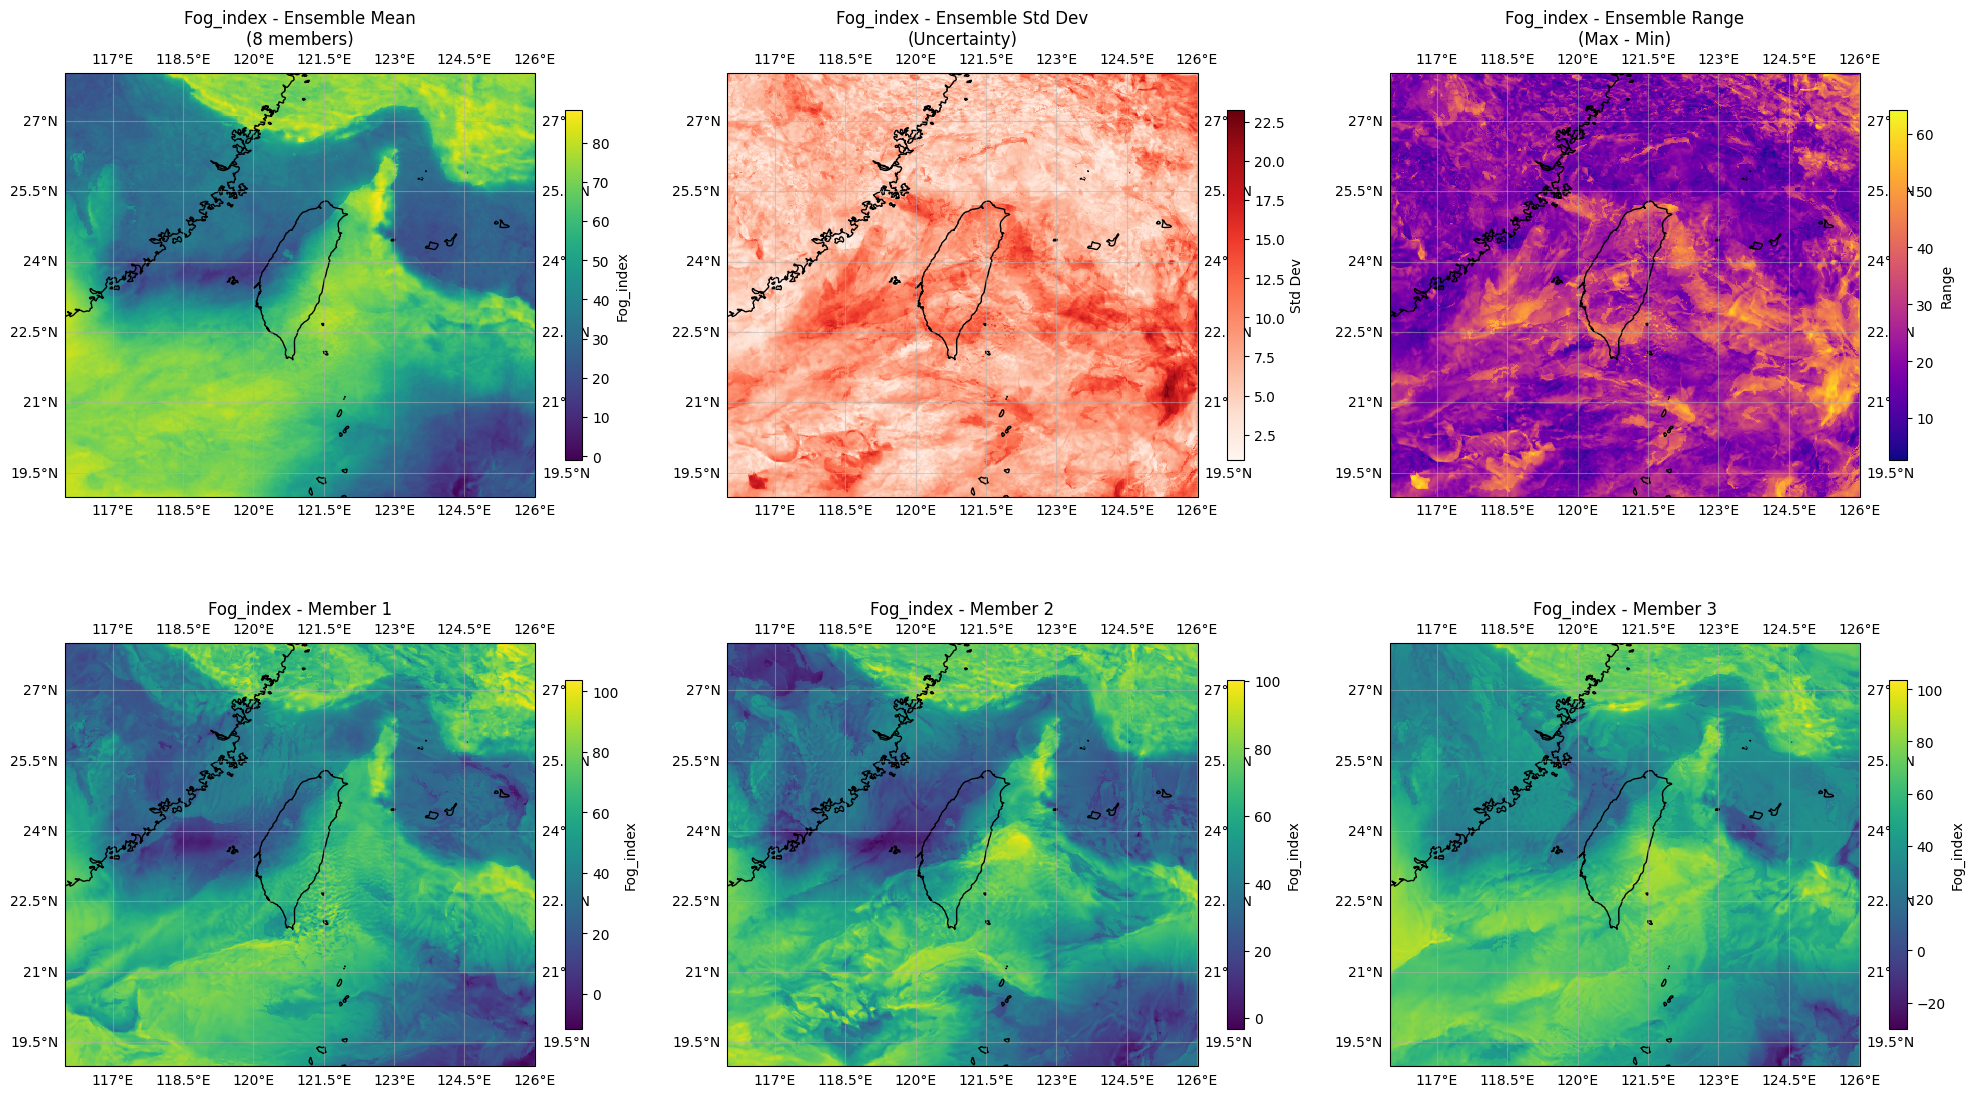

/tmp/ipykernel_8357/229464886.py:82: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if pred_ds.dims['time'] > 1:
/tmp/ipykernel_8357/229464886.py:93: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ax.plot(range(pred_ds.dims['time']), spatial_means.isel(ensemble=i),


ValueError: x and y must have same first dimension, but have shapes (3,) and (1,)

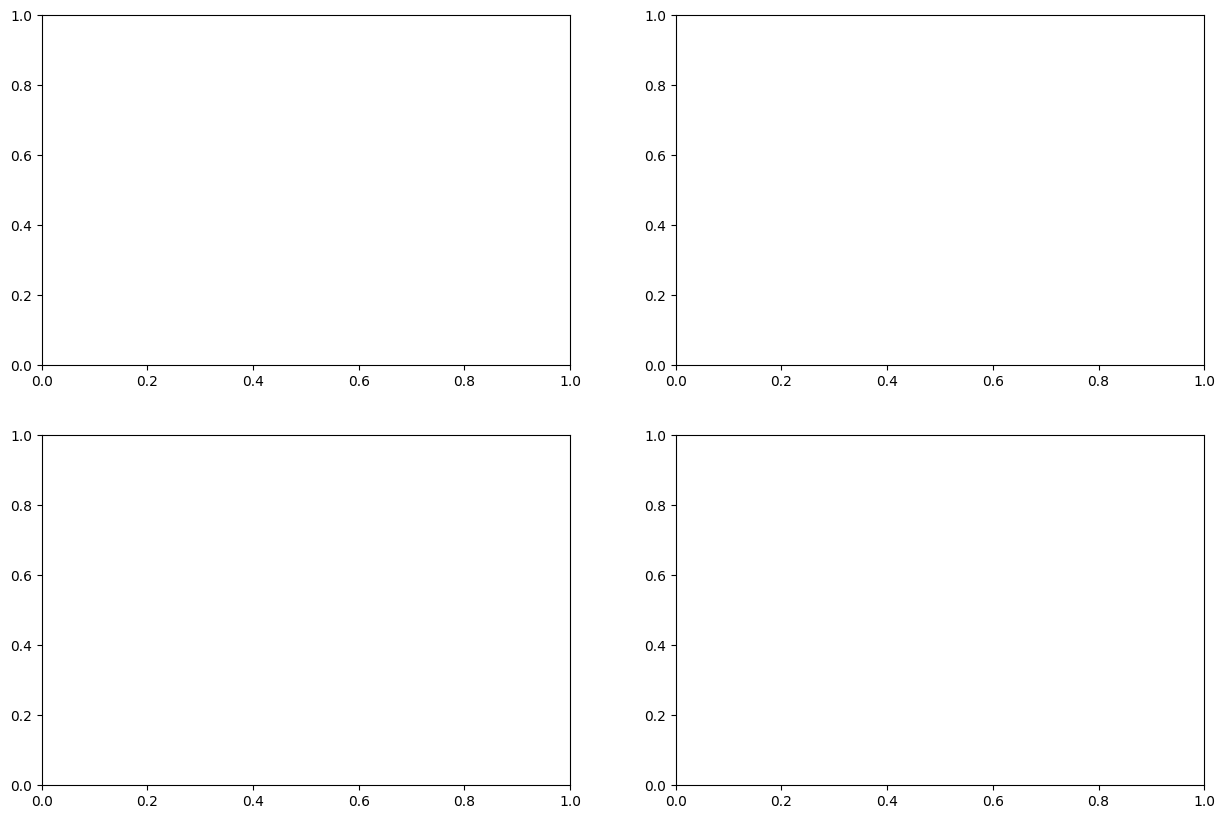

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ensemble_analysis(netcdf_path, time_idx=0, save_prefix='ensemble_analysis'):
    """Create comprehensive ensemble analysis plots"""
    
    print(f'🎨 Creating ensemble visualization for time index {time_idx}...')
    
    # Load data
    pred_ds = xr.open_dataset(netcdf_path, group='prediction')
    input_ds = xr.open_dataset(netcdf_path, group='input')
    
    # Use first output variable for visualization
    var_name = OUTPUT_VARIABLES[0]
    var_data = pred_ds[var_name].isel(time=time_idx)  # Shape: (ensemble, y, x)
    
    # Compute statistics
    ens_mean = var_data.mean(dim='ensemble')
    ens_std = var_data.std(dim='ensemble')
    ens_min = var_data.min(dim='ensemble')
    ens_max = var_data.max(dim='ensemble')
    
    # Setup projection
    central_lon = (ensemble_corrdiff.output_lon.min() + ensemble_corrdiff.output_lon.max()) / 2
    central_lat = (ensemble_corrdiff.output_lat.min() + ensemble_corrdiff.output_lat.max()) / 2
    projection = ccrs.PlateCarree(central_longitude=central_lon)
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(20, 12))
    
    # 1. Ensemble Mean
    ax1 = fig.add_subplot(2, 3, 1, projection=projection)
    c1 = ax1.pcolormesh(pred_ds.x, pred_ds.y, ens_mean, 
                       transform=ccrs.PlateCarree(), cmap='viridis')
    ax1.coastlines()
    ax1.gridlines(draw_labels=True, alpha=0.5)
    ax1.add_feature(cfeature.BORDERS, alpha=0.5)
    ax1.set_title(f'{var_name} - Ensemble Mean\n({NUM_ENSEMBLES} members)')
    plt.colorbar(c1, ax=ax1, shrink=0.6, label=var_name)
    
    # 2. Ensemble Standard Deviation
    ax2 = fig.add_subplot(2, 3, 2, projection=projection)
    c2 = ax2.pcolormesh(pred_ds.x, pred_ds.y, ens_std, 
                       transform=ccrs.PlateCarree(), cmap='Reds')
    ax2.coastlines()
    ax2.gridlines(draw_labels=True, alpha=0.5)
    ax2.add_feature(cfeature.BORDERS, alpha=0.5)
    ax2.set_title(f'{var_name} - Ensemble Std Dev\n(Uncertainty)')
    plt.colorbar(c2, ax=ax2, shrink=0.6, label='Std Dev')
    
    # 3. Ensemble Range (Max - Min)
    ax3 = fig.add_subplot(2, 3, 3, projection=projection)
    c3 = ax3.pcolormesh(pred_ds.x, pred_ds.y, ens_max - ens_min,
                       transform=ccrs.PlateCarree(), cmap='plasma')
    ax3.coastlines()
    ax3.gridlines(draw_labels=True, alpha=0.5)
    ax3.add_feature(cfeature.BORDERS, alpha=0.5)
    ax3.set_title(f'{var_name} - Ensemble Range\n(Max - Min)')
    plt.colorbar(c3, ax=ax3, shrink=0.6, label='Range')
    
    # 4. Individual Ensemble Members (show first 3)
    for i in range(min(3, NUM_ENSEMBLES)):
        ax = fig.add_subplot(2, 3, 4+i, projection=projection)
        c = ax.pcolormesh(pred_ds.x, pred_ds.y, var_data.isel(ensemble=i),
                         transform=ccrs.PlateCarree(), cmap='viridis')
        ax.coastlines()
        ax.gridlines(draw_labels=True, alpha=0.5)
        ax.add_feature(cfeature.BORDERS, alpha=0.5)
        ax.set_title(f'{var_name} - Member {i+1}')
        plt.colorbar(c, ax=ax, shrink=0.6, label=var_name)
    
    plt.tight_layout()
    
    # Save the plot
    output_plot = f'/app/outputs/{save_prefix}_spatial_{time_idx}.jpg'
    plt.savefig(output_plot, dpi=150, bbox_inches='tight')
    print(f'   ✅ Spatial analysis saved to: {output_plot}')
    plt.show()
    
    # Create time series plot if multiple time steps
    if pred_ds.dims['time'] > 1:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Compute spatial means over time
        spatial_means = var_data.mean(dim=['y', 'x'])  # Shape: (ensemble, time)
        time_mean = spatial_means.mean(dim='ensemble')
        time_std = spatial_means.std(dim='ensemble')
        
        # Plot ensemble spaghetti
        ax = axes[0, 0]
        for i in range(NUM_ENSEMBLES):
            ax.plot(range(pred_ds.dims['time']), spatial_means.isel(ensemble=i), 
                   alpha=0.6, linewidth=1, label=f'Member {i+1}' if i < 5 else None)
        ax.plot(range(pred_ds.dims['time']), time_mean, 'k-', linewidth=3, label='Ensemble Mean')
        ax.set_xlabel('Time Step')
        ax.set_ylabel(f'{var_name} (Spatial Mean)')
        ax.set_title('Ensemble Time Series (Spatial Average)')
        if NUM_ENSEMBLES <= 5:
            ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot uncertainty evolution
        ax = axes[0, 1]
        ax.plot(range(pred_ds.dims['time']), time_std, 'r-', linewidth=2)
        ax.fill_between(range(pred_ds.dims['time']), 
                       time_mean - time_std, time_mean + time_std, alpha=0.3)
        ax.set_xlabel('Time Step')
        ax.set_ylabel('Ensemble Std Dev')
        ax.set_title('Uncertainty Evolution')
        ax.grid(True, alpha=0.3)
        
        # Distribution at first and last time step
        ax = axes[1, 0]
        ax.hist(spatial_means.isel(time=0).values, bins=20, alpha=0.7, 
               label=f'Time 0', density=True)
        if pred_ds.dims['time'] > 1:
            ax.hist(spatial_means.isel(time=-1).values, bins=20, alpha=0.7, 
                   label=f'Time {pred_ds.dims["time"]-1}', density=True)
        ax.set_xlabel(f'{var_name} Value')
        ax.set_ylabel('Density')
        ax.set_title('Ensemble Distribution Evolution')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Rank histogram
        ax = axes[1, 1]
        # Simplified rank histogram - count how often each member is minimum
        ranks = np.zeros(NUM_ENSEMBLES)
        for t in range(pred_ds.dims['time']):
            sorted_indices = np.argsort(spatial_means.isel(time=t).values)
            for rank, idx in enumerate(sorted_indices):
                ranks[rank] += 1
        ax.bar(range(NUM_ENSEMBLES), ranks)
        ax.set_xlabel('Rank (0=lowest, n-1=highest)')
        ax.set_ylabel('Frequency')
        ax.set_title('Rank Histogram')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save time series plot
        output_ts_plot = f'/app/outputs/{save_prefix}_timeseries.jpg'
        plt.savefig(output_ts_plot, dpi=150, bbox_inches='tight')
        print(f'   ✅ Time series analysis saved to: {output_ts_plot}')
        plt.show()
    
    # Cleanup
    pred_ds.close()
    input_ds.close()

# Create comprehensive visualization
plot_ensemble_analysis(saved_file, time_idx=0)

# If multiple time steps, show evolution
if len(results['times']) > 1:
    print(f'\n📈 Ensemble statistics across {len(results["times"])} time steps:')
    for var_name in OUTPUT_VARIABLES:
        if var_name in ensemble_stats:
            mean_vals = ensemble_stats[var_name]['mean']
            std_vals = ensemble_stats[var_name]['std']
            print(f'   {var_name}:')
            print(f'     Time-averaged mean: {mean_vals.mean().values:.4f} ± {std_vals.mean().values:.4f}')
            print(f'     Max uncertainty: {std_vals.max().values:.4f}')
            print(f'     Mean spread: {ensemble_stats[var_name]["range"].mean().values:.4f}')

## Summary and Next Steps

In [11]:
print('🎉 ENSEMBLE CORRDIFF INFERENCE COMPLETE!')
print('=' * 60)
print(f'📊 Configuration Summary:')
print(f'   • Ensemble members: {NUM_ENSEMBLES}')
print(f'   • Sampling mode: {SAMPLING_MODE}')
print(f'   • Diffusion steps: {NUMBER_OF_STEPS}')
print(f'   • Time steps processed: {len(results["times"])}')
print(f'   • Variables: {OUTPUT_VARIABLES}')

print(f'💾 Output Files:')
print(f'   • Main results: {saved_file}')
print(f'   • Visualization: /app/outputs/ensemble_analysis_spatial_*.jpg')

print(f'📈 Key Insights:')
for var_name in OUTPUT_VARIABLES:
    if var_name in ensemble_stats:
        stats = ensemble_stats[var_name]
        uncertainty = stats['std'].mean().values
        spread = stats['range'].mean().values
        print(f'   • {var_name}: Average uncertainty = {uncertainty:.4f}, Average spread = {spread:.4f}')

print(f'\n🔄 To load and analyze the results:')
print(f'```python')
print(f'import xarray as xr')
print(f'# Load ensemble predictions')
print(f'pred_ds = xr.open_dataset("{saved_file}", group="prediction")')
print(f'input_ds = xr.open_dataset("{saved_file}", group="input")')
print(f'# Access ensemble data')
print(f'ensemble_data = pred_ds["{OUTPUT_VARIABLES[0]}"]  # Shape: (ensemble, time, y, x)')
print(f'```')

print(f'\n🚀 Next Steps:')
print(f'   1. Experiment with different SAMPLING_MODE (deterministic vs stochastic)')
print(f'   2. Adjust NUM_ENSEMBLES for your uncertainty requirements')
print(f'   3. Modify NUMBER_OF_STEPS to balance quality vs speed')
print(f'   4. Use the saved NetCDF file for further analysis or visualization')
print(f'   5. Compare ensemble spreads with observation uncertainties')

print('=' * 60)

🎉 ENSEMBLE CORRDIFF INFERENCE COMPLETE!
📊 Configuration Summary:
   • Ensemble members: 8
   • Sampling mode: stochastic
   • Diffusion steps: 20
   • Time steps processed: 3
   • Variables: ['Fog_index']
💾 Output Files:
   • Main results: /app/outputs/generation/Fog_index/ensemble_Fog_index_predictions_20260203_072846.nc
   • Visualization: /app/outputs/ensemble_analysis_spatial_*.jpg
📈 Key Insights:
   • Fog_index: Average uncertainty = 7.8851, Average spread = 24.7525

🔄 To load and analyze the results:
```python
import xarray as xr
# Load ensemble predictions
pred_ds = xr.open_dataset("/app/outputs/generation/Fog_index/ensemble_Fog_index_predictions_20260203_072846.nc", group="prediction")
input_ds = xr.open_dataset("/app/outputs/generation/Fog_index/ensemble_Fog_index_predictions_20260203_072846.nc", group="input")
# Access ensemble data
ensemble_data = pred_ds["Fog_index"]  # Shape: (ensemble, time, y, x)
```

🚀 Next Steps:
   1. Experiment with different SAMPLING_MODE (determini